# PMI、CPI、工业增加值与 PPI：Hamilton 滤波和区制切换

流程：读取四个 pkl → 月度化 → Z-score 标准化 → Hamilton (2018) 回归滤波 → 两区制 Markov Switching 模型 → 输出图表、参数和当前宏观结论。

> 说明：Hamilton 月度参数使用 `h=8, p=4`。区制模型允许截距和方差随区制切换，并使用平滑概率判断当前区制。

In [54]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
PKL_DIR = ROOT / "output_宏观_pkl"
OUT_DIR = ROOT / "四指标_区制切换_output"
OUT_DIR.mkdir(exist_ok=True)

# 按用户指定的对应关系
SERIES_INFO = {
    "M0000612": "CPI",
    "M0017126": "PMI",
    "M0000545": "工业增加值",
    "M0001227": "PPI",
}

LATEST_DATE = pd.Timestamp("2026-05-31")  # pkl 第一条记录对应的日期
ANALYSIS_START = pd.Timestamp("2005-01-31")  # 四个指标统一起点
H, P = 8, 4
PROB_THRESHOLD = 0.50
RANDOM_SEED = 20260709  # 固定多初值搜索，保证相同数据重复运行得到相同结果
print("数据目录：", PKL_DIR.resolve())
print("输出目录：", OUT_DIR.resolve())

数据目录： C:\Users\16492\Desktop\实习内容\finance_intership\output_宏观_pkl
输出目录： C:\Users\16492\Desktop\实习内容\finance_intership\四指标_区制切换_output


## 核心函数

读取函数兼容 Series、单列/多列 DataFrame，以及无法直接解析为日期的倒序月度数据。若 pkl 索引没有日期，会假定第一条是最新值，并以当前月末向前生成月度索引。

In [55]:
def first_numeric_series(obj):
    """从常见 pkl 对象中提取有效数值序列。"""
    if isinstance(obj, pd.Series):
        return pd.to_numeric(obj, errors="coerce")
    if isinstance(obj, pd.DataFrame):
        numeric = obj.apply(pd.to_numeric, errors="coerce")
        candidates = [c for c in numeric.columns if numeric[c].notna().sum() > 0]
        if not candidates:
            raise ValueError("DataFrame 中没有可用的数值列")
        return numeric[max(candidates, key=lambda c: numeric[c].notna().sum())]
    return pd.to_numeric(pd.Series(obj), errors="coerce")


def read_monthly_pkl(code):
    path = PKL_DIR / f"{code}.pkl"
    if not path.exists():
        raise FileNotFoundError(f"未找到：{path}")
    raw = first_numeric_series(pd.read_pickle(path)).dropna()
    if raw.empty:
        raise ValueError(f"{code} 没有有效数值")

    original_index = pd.Index(raw.index)
    # RangeIndex/整数序号不能直接交给 to_datetime，否则会被误读为 1970 年附近的纳秒时间。
    looks_numeric = isinstance(original_index, pd.RangeIndex) or pd.api.types.is_numeric_dtype(original_index.dtype)
    parsed = pd.DatetimeIndex([pd.NaT] * len(raw)) if looks_numeric else pd.to_datetime(original_index.astype(str), errors="coerce")
    plausible_dates = parsed.notna() & (parsed.year >= 1900) & (parsed.year <= pd.Timestamp.today().year + 1)
    if plausible_dates.mean() >= 0.80:
        values = np.ascontiguousarray(raw.to_numpy(dtype=float))
        s = pd.Series(values, index=parsed)
        s = s[s.index.notna()]
    else:
        # 本项目的无日期 pkl 通常按“最新到最早”保存
        dates = [LATEST_DATE - pd.offsets.MonthEnd(i) for i in range(len(raw))]
        values = np.ascontiguousarray(raw.to_numpy(dtype=float))
        s = pd.Series(values, index=pd.DatetimeIndex(dates))

    s.index = s.index.to_period("M").to_timestamp("M")
    # 不使用 groupby.last：部分 pandas 版本处理倒序产生的非连续数组时会报
    # “ndarray is not C-contiguous”。月度索引去重即可达到相同目的。
    s = s[~s.index.duplicated(keep="last")].sort_index().copy()
    full_index = pd.date_range(s.index.min(), s.index.max(), freq="ME")
    return s.reindex(full_index).interpolate(limit=2).dropna().rename(code)


def load_aligned_raw_series(series_info=SERIES_INFO, start=ANALYSIS_START):
    """从指定起点取四个指标的共同非空月度样本，保证时点严格一致。"""
    loaded = {
        code: read_monthly_pkl(code).loc[lambda s: s.index >= start]
        for code in series_info
    }
    aligned = pd.concat(loaded, axis=1, join="inner").dropna(how="any")
    aligned.columns = list(loaded.keys())
    if aligned.empty:
        raise ValueError("2005 年以后没有四个指标共同存在的有效月份")
    if aligned.index[0] > start:
        print(f"提示：受最晚开始指标限制，共同样本实际从 {aligned.index[0]:%Y-%m-%d} 开始。")
    print(f"四指标共同样本：{aligned.index[0]:%Y-%m-%d} 至 {aligned.index[-1]:%Y-%m-%d}，共 {len(aligned)} 个月")
    return aligned


def zscore(s):
    sd = s.std(ddof=0)
    if not np.isfinite(sd) or sd == 0:
        raise ValueError(f"{s.name} 的标准差为 0，无法标准化")
    return ((s - s.mean()) / sd).rename("standardized")


def hamilton_filter(y, h=8, p=4):
    """以 y[t+h] 对常数项及 y[t],...,y[t-p+1] 回归，残差为周期项。"""
    y = y.astype(float).dropna()
    rows, targets, dates = [], [], []
    for t in range(p - 1, len(y) - h):
        rows.append([1.0] + [y.iloc[t - lag] for lag in range(p)])
        targets.append(y.iloc[t + h])
        dates.append(y.index[t + h])
    if len(rows) <= p + 2:
        raise ValueError(f"{y.name} 样本不足，无法进行 Hamilton 回归")
    X = np.asarray(rows, dtype=float)
    target = np.asarray(targets, dtype=float)
    beta = np.linalg.lstsq(X, target, rcond=None)[0]
    trend = pd.Series(X @ beta, index=pd.DatetimeIndex(dates), name="hamilton_trend")
    cycle = (y.reindex(trend.index) - trend).rename("hamilton_cycle")
    return cycle, trend, beta


def fit_markov_switching(cycle):
    """标准两区制模型：区制均值和误差方差均可切换。"""
    model = MarkovRegression(
        cycle.dropna(), k_regimes=2, trend="c", switching_variance=True
    )
    model.initialize_known(np.array([0.5, 0.5]))
    # 多组初值搜索固定随机种子，保证相同数据与设定下结果可复现。
    np.random.seed(RANDOM_SEED)
    result = model.fit(search_reps=60, search_iter=15, em_iter=0, maxiter=2000, disp=False)
    params = pd.Series(result.params, index=model.param_names)
    means = np.array([params.get("const[0]", np.nan), params.get("const[1]", np.nan)])
    low_regime, high_regime = np.argsort(means)

    probs = result.smoothed_marginal_probabilities
    if not isinstance(probs, pd.DataFrame):
        probs = pd.DataFrame(probs, index=cycle.dropna().index, columns=[0, 1])
    else:
        probs.index = cycle.dropna().index

    states = pd.DataFrame(index=cycle.dropna().index)
    states["hamilton_cycle"] = cycle.dropna()
    states["prob_low"] = probs.iloc[:, low_regime].to_numpy()
    states["prob_high"] = probs.iloc[:, high_regime].to_numpy()
    states["regime"] = np.where(states["prob_high"] >= PROB_THRESHOLD, "高位区制", "低位区制")

    p00 = params.get("p[0->0]", np.nan)
    p10 = params.get("p[1->0]", np.nan)
    transition = np.array([[p00, 1 - p00], [p10, 1 - p10]])
    stay_low = transition[low_regime, low_regime]
    stay_high = transition[high_regime, high_regime]
    summary = {
        "log_likelihood": result.llf,
        "aic": result.aic,
        "bic": result.bic,
        "low_mean": means[low_regime],
        "high_mean": means[high_regime],
        "p_stay_low": stay_low,
        "p_stay_high": stay_high,
        "expected_low_months": 1 / max(1 - stay_low, 1e-8),
        "expected_high_months": 1 / max(1 - stay_high, 1e-8),
        "converged": bool(result.mle_retvals.get("converged", False)),
    }
    return result, states, summary


## 批量拟合、保存结果并生成结论

四指标共同样本：2005-01-31 至 2026-03-31，共 255 个月


c:\Users\16492\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\16492\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\16492\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\16492\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


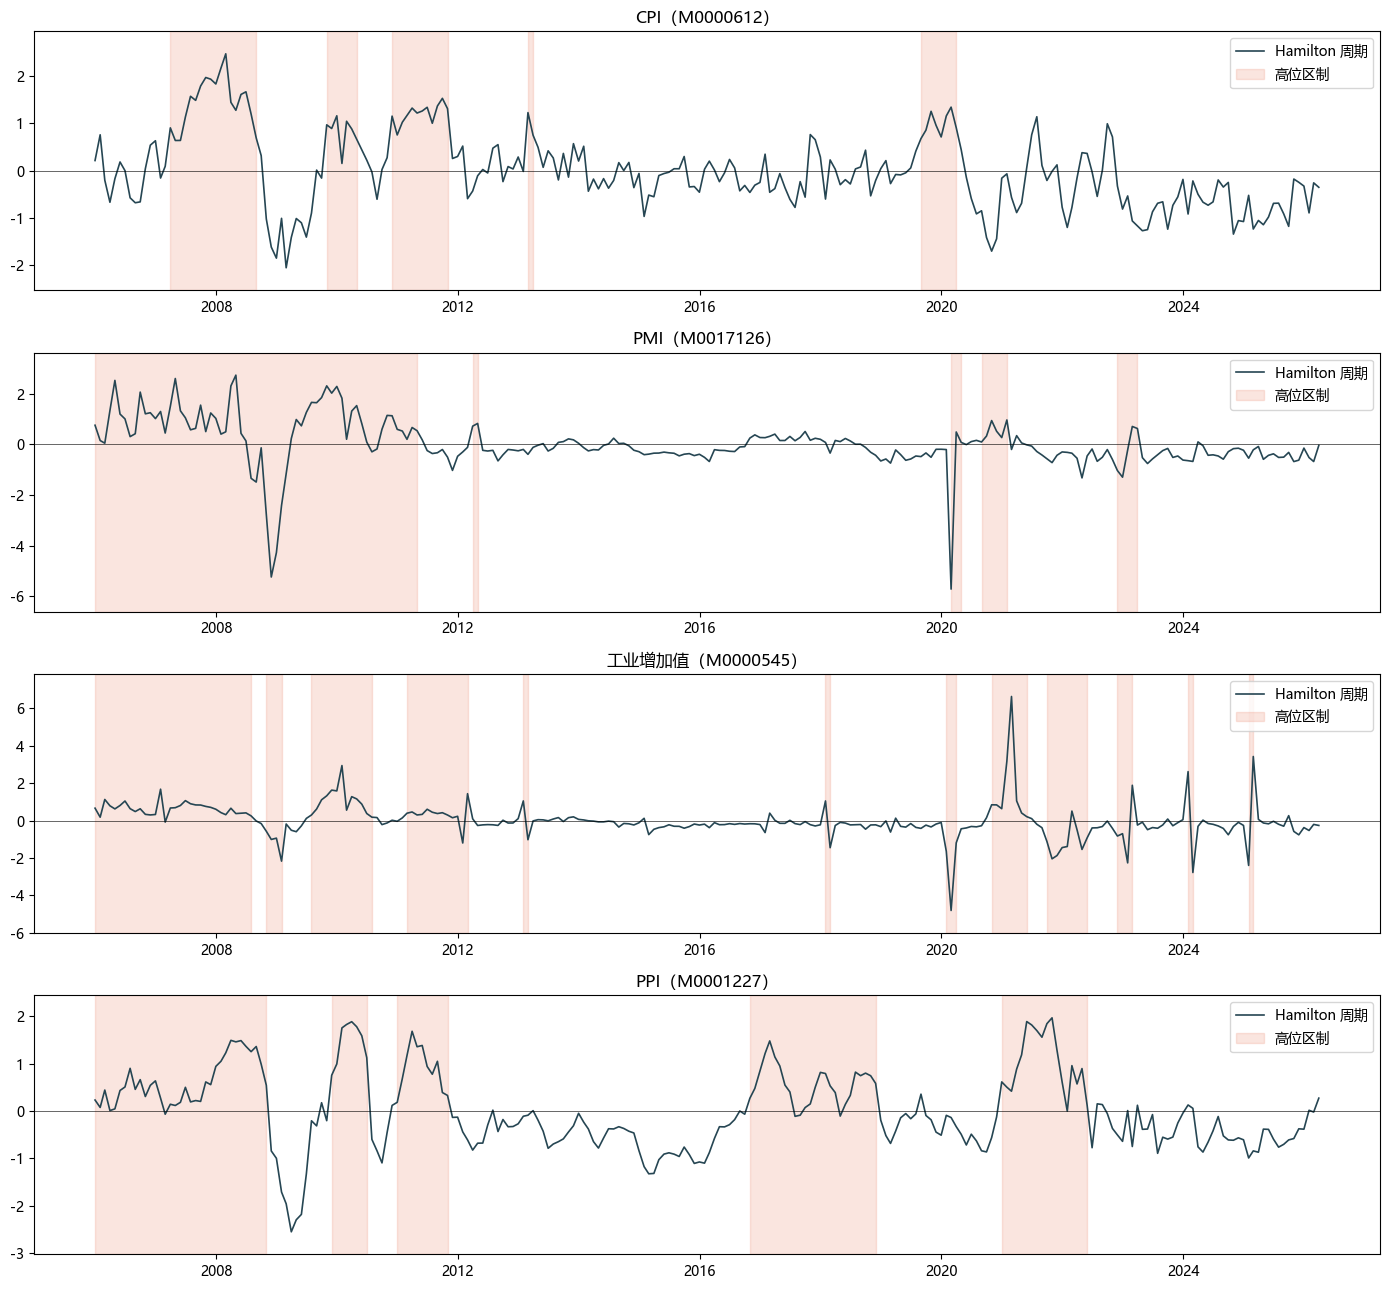

模型结论：增长动能整体偏弱；价格动能整体偏低。多数指标处于低位区制，宏观景气偏弱。
注：结论描述的是标准化后 Hamilton 周期项的相对高低区制，不等同于原指标同比值的绝对涨跌。


,code,indicator,latest_date,latest_raw,hamilton_cycle,regime,prob_high,economic_reading
0,M0000612,CPI,2026-03-31 00:00:00,1.000,-0.352,低位区制,0.0%,偏弱/偏低
1,M0017126,PMI,2026-03-31 00:00:00,50.400,-0.040,低位区制,1.0%,偏弱/偏低
2,M0000545,工业增加值,2026-03-31 00:00:00,5.700,-0.260,低位区制,1.8%,偏弱/偏低
3,M0001227,PPI,2026-03-31 00:00:00,0.500,0.273,低位区制,12.8%,偏弱/偏低


,code,indicator,log_likelihood,aic,bic,low_mean,high_mean,p_stay_low,p_stay_high,expected_low_months,expected_high_months,converged
0,M0000612,CPI,-228.822,469.644,490.627,-0.298,1.139,0.971,0.885,34.606,8.699,True
1,M0017126,PMI,-213.155,438.310,459.293,-0.237,0.460,0.974,0.941,39.185,16.865,True
2,M0000545,工业增加值,-204.216,420.432,441.415,-0.188,0.263,0.914,0.875,11.692,8.008,True
3,M0001227,PPI,-210.865,433.731,454.714,-0.522,0.765,0.969,0.948,32.410,19.296,True


In [56]:
aligned_raw_data = load_aligned_raw_series()

all_states = []
model_summaries = []
latest_rows = []
fitted_models = {}

fig, axes = plt.subplots(len(SERIES_INFO), 1, figsize=(14, 13), sharex=False)

for ax, (code, name) in zip(axes, SERIES_INFO.items()):
    raw = aligned_raw_data[code].rename(code)
    standardized = zscore(raw)
    cycle, trend, beta = hamilton_filter(standardized, H, P)
    result, states, summary = fit_markov_switching(cycle)
    fitted_models[code] = result

    states.insert(0, "indicator", name)
    states.insert(0, "code", code)
    states["raw_value"] = raw.reindex(states.index)
    states["standardized"] = standardized.reindex(states.index)
    states["hamilton_trend"] = trend.reindex(states.index)
    all_states.append(states.reset_index(names="date"))

    latest = states.iloc[-1]
    direction = "偏强/偏高" if latest["regime"] == "高位区制" else "偏弱/偏低"
    latest_rows.append({
        "code": code,
        "indicator": name,
        "latest_date": states.index[-1],
        "latest_raw": latest["raw_value"],
        "hamilton_cycle": latest["hamilton_cycle"],
        "regime": latest["regime"],
        "prob_high": latest["prob_high"],
        "economic_reading": direction,
    })
    model_summaries.append({"code": code, "indicator": name, **summary})

    ax.plot(states.index, states["hamilton_cycle"], color="#264653", lw=1.2, label="Hamilton 周期")
    ax.axhline(0, color="black", lw=0.7, alpha=0.6)
    ax.fill_between(
        states.index, 0, 1,
        where=states["prob_high"].to_numpy() >= PROB_THRESHOLD,
        color="#e76f51", alpha=0.18, transform=ax.get_xaxis_transform(),
        label="高位区制",
    )
    ax.set_title(f"{name}（{code}）")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig(OUT_DIR / "四指标_Hamilton周期与区制.png", dpi=180, bbox_inches="tight")
plt.show()

states_table = pd.concat(all_states, ignore_index=True)
summary_table = pd.DataFrame(model_summaries)
latest_table = pd.DataFrame(latest_rows)

states_table.to_csv(OUT_DIR / "四指标_逐月区制概率.csv", index=False, encoding="utf-8-sig")
summary_table.to_csv(OUT_DIR / "四指标_模型参数摘要.csv", index=False, encoding="utf-8-sig")
latest_table.to_csv(OUT_DIR / "四指标_最新区制结论.csv", index=False, encoding="utf-8-sig")

high_count = int((latest_table["regime"] == "高位区制").sum())
growth_high = latest_table.loc[latest_table["indicator"].isin(["PMI", "工业增加值"]), "regime"].eq("高位区制").sum()
price_high = latest_table.loc[latest_table["indicator"].isin(["CPI", "PPI"]), "regime"].eq("高位区制").sum()

growth_text = {0: "增长动能整体偏弱", 1: "增长信号分化", 2: "增长动能整体偏强"}[int(growth_high)]
price_text = {0: "价格动能整体偏低", 1: "价格信号分化", 2: "价格动能整体偏高"}[int(price_high)]
overall_text = (
    "多数指标处于高位区制，宏观景气偏强。" if high_count >= 3 else
    "多数指标处于低位区制，宏观景气偏弱。" if high_count <= 1 else
    "高低位指标各半，宏观状态分化，暂不宜给出单边判断。"
)

conclusion = f"模型结论：{growth_text}；{price_text}。{overall_text}"
print(conclusion)
print("注：结论描述的是标准化后 Hamilton 周期项的相对高低区制，不等同于原指标同比值的绝对涨跌。")
display(latest_table.style.format({"latest_raw": "{:.3f}", "hamilton_cycle": "{:.3f}", "prob_high": "{:.1%}"}))
display(summary_table.style.format(precision=3))

with open(OUT_DIR / "四指标_综合结论.txt", "w", encoding="utf-8") as f:
    f.write(conclusion + "\n")
    f.write("结论基于标准化后 Hamilton 周期项的两区制 Markov Switching 模型。\n")

## 可选：查看单个模型的完整估计结果

若某项模型未收敛，先增加 `search_reps`，再检查异常值与样本长度。

In [57]:
# 示例：查看 PMI 模型的完整统计摘要
pmi_code = next(code for code, name in SERIES_INFO.items() if name == "PMI")
print(fitted_models[pmi_code].summary())

                        Markov Switching Model Results                        
Dep. Variable:         hamilton_cycle   No. Observations:                  244
Model:               MarkovRegression   Log Likelihood                -213.155
Date:                Thu, 09 Jul 2026   AIC                            438.310
Time:                        10:43:08   BIC                            459.293
Sample:                    12-31-2005   HQIC                           446.761
                         - 03-31-2026                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4604      0.165      2.785      0.005       0.136       0.784
sigma2         2.1742      0.359      6.064      0.0

## 两种区制切换模型的对比

**模型 A（均值—方差切换）**：

$$c_t=\mu_{S_t}+\varepsilon_{t,S_t}$$

**模型 B（共同 AR(1) 系数的区制切换回归）**：

$$c_t=\alpha_{S_t}+\phi c_{t-1}+\varepsilon_{t,S_t}$$

模型 B 的截距和误差方差允许随区制变化，但两个区制共享同一个 AR(1) 系数。这样仍有两条不同的动态方程，同时减少参数和弱识别风险。为了公平比较，模型 A 也在剔除第一个滞后观测后的相同样本上重新估计。区制仍按估计的长期中心从低到高命名。

In [58]:
def _parameter_series(model, result):
    """兼容不同 statsmodels 版本的参数名称。"""
    if isinstance(result.params, pd.Series):
        return result.params.copy()
    return pd.Series(np.asarray(result.params), index=model.param_names)


def _probability_frame(result, index):
    probs = result.smoothed_marginal_probabilities
    values = probs.to_numpy() if isinstance(probs, (pd.DataFrame, pd.Series)) else np.asarray(probs)
    return pd.DataFrame(values, index=index, columns=[0, 1])


def fit_switching_ar1(cycle):
    """两区制 AR(1)：截距和方差切换，AR 系数在两个区制间保持一致。"""
    data = pd.DataFrame({"cycle": cycle.astype(float)})
    data["lag1"] = data["cycle"].shift(1)
    data = data.dropna()

    model = MarkovRegression(
        endog=data["cycle"],
        k_regimes=2,
        trend="c",
        exog=data[["lag1"]],
        switching_trend=True,
        switching_exog=False,
        switching_variance=True,
    )
    # 使用中性初始状态概率，避免边界转移矩阵无法构造稳态概率。
    model.initialize_known(np.array([0.5, 0.5]))
    # statsmodels 的 search_reps 会随机生成初值；必须固定种子才可复现。
    np.random.seed(RANDOM_SEED)
    # 关闭默认 EM 预迭代：切换回归在退化初值下可能形成奇异矩阵并触发 SVD did not converge。
    result = model.fit(search_reps=100, search_iter=20, em_iter=0, maxiter=3000, disp=False)
    params = _parameter_series(model, result)

    intercepts = np.array([params.get(f"const[{r}]", np.nan) for r in range(2)])
    # 不同 statsmodels 版本可能把共同系数命名为 x1、lag1，甚至 x1[1]。
    ar_names = [n for n in params.index if n == "x1" or n == "lag1" or n.startswith("x1[") or n.startswith("lag1[")]
    common_phi = params[ar_names[0]] if ar_names else np.nan
    phis = np.repeat(common_phi, 2)
    # 平稳时使用 alpha/(1-phi)；接近单位根时使用样本均值处的条件中心，避免数值爆炸。
    centers = np.where(
        np.abs(phis) < 0.98,
        intercepts / (1.0 - phis),
        intercepts + phis * data["lag1"].mean(),
    )
    low_regime, high_regime = np.argsort(centers)
    probs = _probability_frame(result, data.index)

    states = data.copy()
    states["prob_low"] = probs.iloc[:, low_regime].to_numpy()
    states["prob_high"] = probs.iloc[:, high_regime].to_numpy()
    states["regime"] = np.where(states["prob_high"] >= PROB_THRESHOLD, "高位区制", "低位区制")

    detail = {
        "result": result,
        "states": states,
        "low_regime_number": int(low_regime),
        "high_regime_number": int(high_regime),
        "low_intercept": intercepts[low_regime],
        "low_ar1": phis[low_regime],
        "low_long_run_center": centers[low_regime],
        "high_intercept": intercepts[high_regime],
        "high_ar1": phis[high_regime],
        "high_long_run_center": centers[high_regime],
        "aic": result.aic,
        "bic": result.bic,
        "log_likelihood": result.llf,
        "converged": bool(result.mle_retvals.get("converged", False)),
    }
    return detail

c:\Users\16492\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\16492\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\16492\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\16492\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\16492\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  

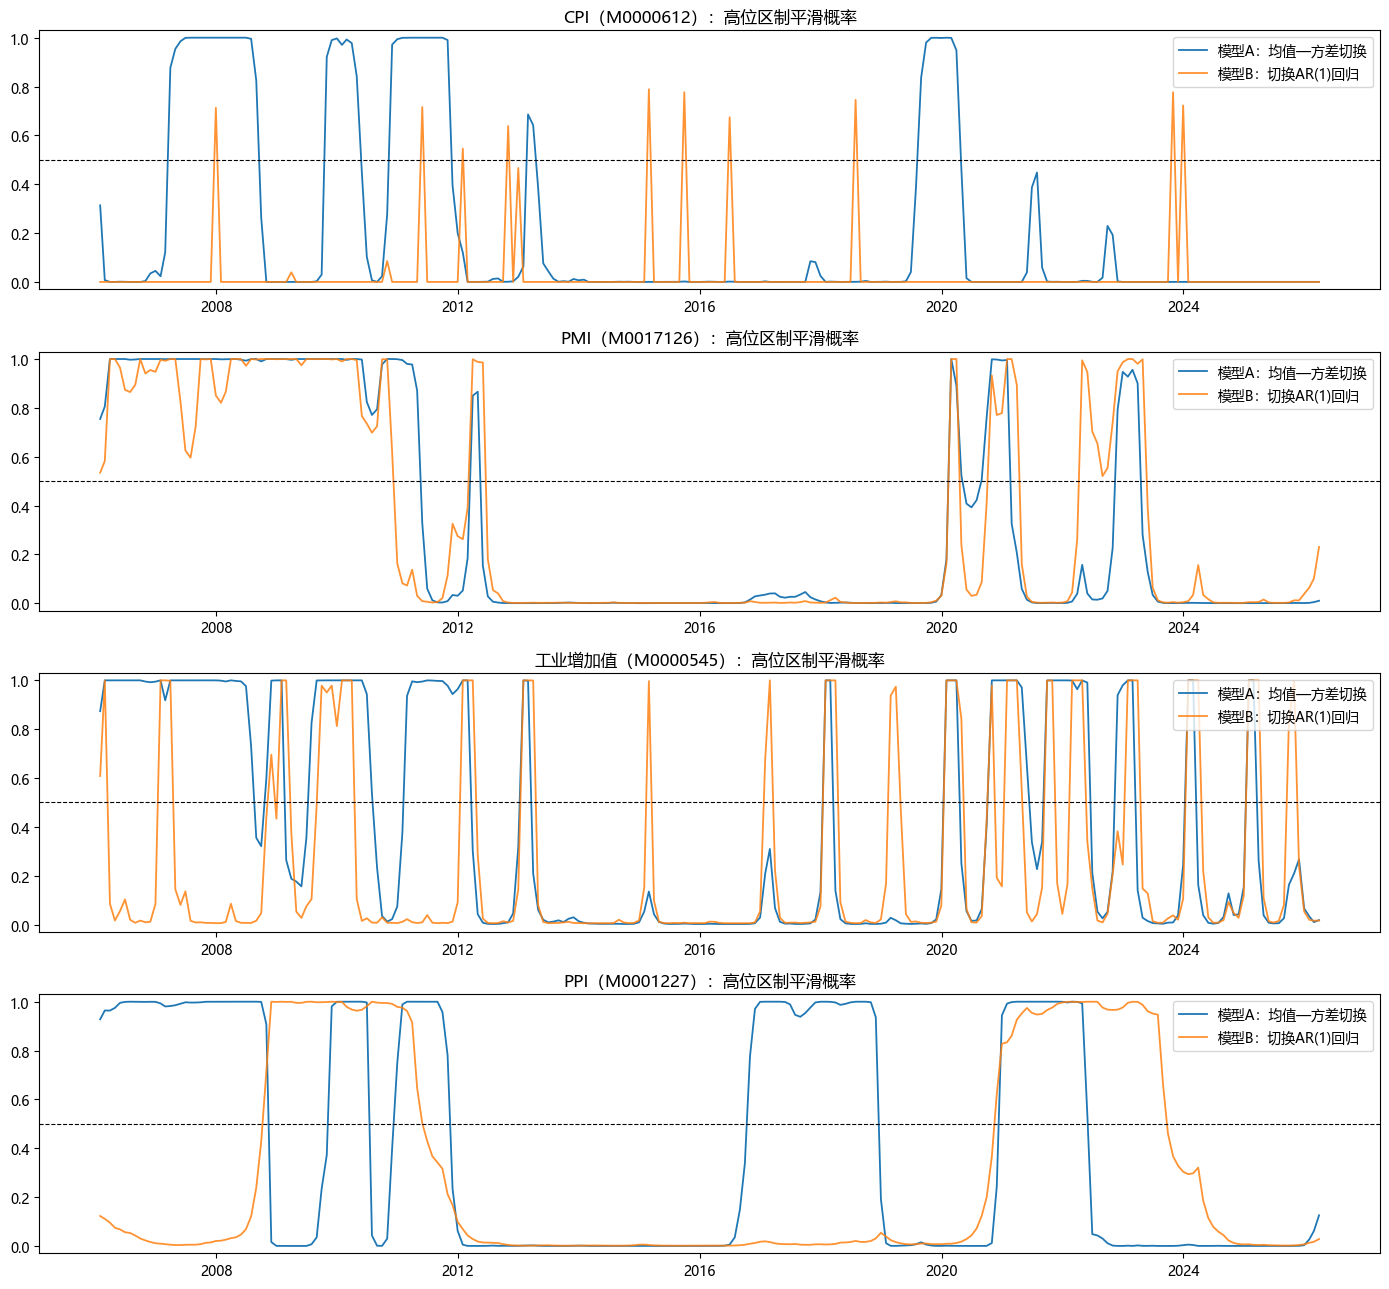

最新区制判断中，两个模型在 4/4 个指标上结论一致；按惩罚更严格的 BIC，区制切换 AR(1) 模型在 4/4 个指标上更优。
模型A：仅均值和方差切换；模型B：截距和方差切换，AR(1)系数共同。


,code,indicator,latest_date,model_A_latest_regime,model_A_prob_high,model_B_latest_regime,model_B_prob_high,latest_conclusion_consistent,historical_regime_agreement,model_A_aic,model_B_aic,aic_preferred,model_A_bic,model_B_bic,bic_preferred,model_B_low_intercept,model_B_low_ar1,model_B_high_intercept,model_B_high_ar1,model_B_converged
0,M0000612,CPI,2026-03-31 00:00:00,低位区制,0.0%,低位区制,0.0%,True,78.2%,467.62,311.31,模型B,488.58,335.76,模型B,-0.011,0.811,0.269,0.811,True
1,M0017126,PMI,2026-03-31 00:00:00,低位区制,1.0%,低位区制,23.1%,True,92.2%,435.03,279.48,模型B,455.99,303.93,模型B,-0.069,0.695,0.128,0.695,True
2,M0000545,工业增加值,2026-03-31 00:00:00,低位区制,1.8%,低位区制,1.7%,True,71.6%,417.37,299.96,模型B,438.32,324.41,模型B,-0.013,0.795,0.024,0.795,True
3,M0001227,PPI,2026-03-31 00:00:00,低位区制,12.5%,低位区制,2.8%,True,60.1%,432.00,156.09,模型B,452.96,180.54,模型B,-0.005,0.914,0.012,0.914,True


In [59]:
comparison_rows = []
comparison_state_frames = []
switching_ar_models = {}

fig, axes = plt.subplots(len(SERIES_INFO), 1, figsize=(14, 13), sharex=False)

for ax, (code, name) in zip(axes, SERIES_INFO.items()):
    raw = aligned_raw_data[code].rename(code)
    standardized = zscore(raw)
    cycle, _, _ = hamilton_filter(standardized, H, P)

    # 模型 B 因 AR(1) 损失首个观测；模型 A 使用同一起点重新拟合。
    aligned_cycle = cycle.iloc[1:].copy()
    result_a, states_a, summary_a = fit_markov_switching(aligned_cycle)
    detail_b = fit_switching_ar1(cycle)
    switching_ar_models[code] = detail_b["result"]
    states_b = detail_b["states"]

    common_index = states_a.index.intersection(states_b.index)
    agreement = (states_a.loc[common_index, "regime"] == states_b.loc[common_index, "regime"]).mean()
    latest_a = states_a.loc[common_index].iloc[-1]
    latest_b = states_b.loc[common_index].iloc[-1]

    model_b_valid = bool(detail_b["converged"])
    preferred_aic = ("模型A" if summary_a["aic"] < detail_b["aic"] else "模型B") if model_b_valid else "模型B未收敛，不比较"
    preferred_bic = ("模型A" if summary_a["bic"] < detail_b["bic"] else "模型B") if model_b_valid else "模型B未收敛，不比较"
    reported_b_regime = latest_b["regime"] if model_b_valid else "未收敛，不给出结论"
    reported_b_prob = latest_b["prob_high"] if model_b_valid else np.nan
    same_latest = (latest_a["regime"] == latest_b["regime"]) if model_b_valid else pd.NA
    comparison_rows.append({
        "code": code,
        "indicator": name,
        "latest_date": common_index[-1],
        "model_A_latest_regime": latest_a["regime"],
        "model_A_prob_high": latest_a["prob_high"],
        "model_B_latest_regime": reported_b_regime,
        "model_B_prob_high": reported_b_prob,
        "latest_conclusion_consistent": same_latest,
        "historical_regime_agreement": agreement,
        "model_A_aic": summary_a["aic"],
        "model_B_aic": detail_b["aic"],
        "aic_preferred": preferred_aic,
        "model_A_bic": summary_a["bic"],
        "model_B_bic": detail_b["bic"],
        "bic_preferred": preferred_bic,
        "model_B_low_intercept": detail_b["low_intercept"],
        "model_B_low_ar1": detail_b["low_ar1"],
        "model_B_high_intercept": detail_b["high_intercept"],
        "model_B_high_ar1": detail_b["high_ar1"],
        "model_B_converged": detail_b["converged"],
    })

    state_compare = pd.DataFrame(index=common_index)
    state_compare["code"] = code
    state_compare["indicator"] = name
    state_compare["hamilton_cycle"] = cycle.reindex(common_index)
    state_compare["model_A_regime"] = states_a.loc[common_index, "regime"]
    state_compare["model_A_prob_high"] = states_a.loc[common_index, "prob_high"]
    state_compare["model_B_regime"] = states_b.loc[common_index, "regime"] if model_b_valid else "未收敛，不给出结论"
    state_compare["model_B_prob_high"] = states_b.loc[common_index, "prob_high"] if model_b_valid else np.nan
    state_compare["model_B_converged"] = model_b_valid
    comparison_state_frames.append(state_compare.reset_index(names="date"))

    ax.plot(common_index, states_a.loc[common_index, "prob_high"], label="模型A：均值—方差切换", lw=1.3)
    ax.plot(common_index, states_b.loc[common_index, "prob_high"], label="模型B：切换AR(1)回归", lw=1.3, alpha=0.85)
    ax.axhline(PROB_THRESHOLD, color="black", ls="--", lw=0.8)
    ax.set_ylim(-0.03, 1.03)
    ax.set_title(f"{name}（{code}）：高位区制平滑概率")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig(OUT_DIR / "两种区制模型_高位概率对比.png", dpi=180, bbox_inches="tight")
plt.show()

model_comparison = pd.DataFrame(comparison_rows)
model_comparison_states = pd.concat(comparison_state_frames, ignore_index=True)
model_comparison.to_csv(OUT_DIR / "两种区制模型_结论对比.csv", index=False, encoding="utf-8-sig")
model_comparison_states.to_csv(OUT_DIR / "两种区制模型_逐月状态对比.csv", index=False, encoding="utf-8-sig")

consistent_count = int(model_comparison["latest_conclusion_consistent"].sum())
preferred_b_count = int((model_comparison["bic_preferred"] == "模型B").sum())
comparison_conclusion = (
    f"最新区制判断中，两个模型在 {consistent_count}/4 个指标上结论一致；"
    f"按惩罚更严格的 BIC，区制切换 AR(1) 模型在 {preferred_b_count}/4 个指标上更优。"
)
print(comparison_conclusion)
print("模型A：仅均值和方差切换；模型B：截距和方差切换，AR(1)系数共同。")
display(model_comparison.style.format({
    "model_A_prob_high": "{:.1%}", "model_B_prob_high": "{:.1%}",
    "historical_regime_agreement": "{:.1%}",
    "model_A_aic": "{:.2f}", "model_B_aic": "{:.2f}",
    "model_A_bic": "{:.2f}", "model_B_bic": "{:.2f}",
    "model_B_low_intercept": "{:.3f}", "model_B_low_ar1": "{:.3f}",
    "model_B_high_intercept": "{:.3f}", "model_B_high_ar1": "{:.3f}",
}))

with open(OUT_DIR / "两种区制模型_比较结论.txt", "w", encoding="utf-8") as f:
    f.write(comparison_conclusion + "\n")
    f.write("AIC/BIC 越小越好；若两者选择不同，优先参考惩罚复杂度更强的 BIC。\n")

## 增长—通胀组合与实际经济状态比较

组合概率定义为：

$$P_t^{growth}=\frac{P_t^{PMI}+P_t^{工业增加值}}{2},\qquad P_t^{inflation}=\frac{P_t^{CPI}+P_t^{PPI}}{2}$$

以 0.5 为高低分界，得到四象限：增长高、通胀低为“复苏”；增长高、通胀高为“过热”；增长低、通胀高为“滞胀”；增长低、通胀低为“衰退”。这里的名称描述**周期相对趋势的位置**，不是对经济衰退的官方认定。

作为同期实际观测基准，本节把四个原始指标在 2005 年以来分别标准化，再构造增长实际得分（PMI 与工业增加值均值）和通胀实际得分（CPI 与 PPI 均值）。得分高于 0 表示高于自身历史平均水平。这个基准不依赖区制模型，但仍来自同一组宏观指标，因此属于内部一致性检验，而非独立的因果或官方周期检验。

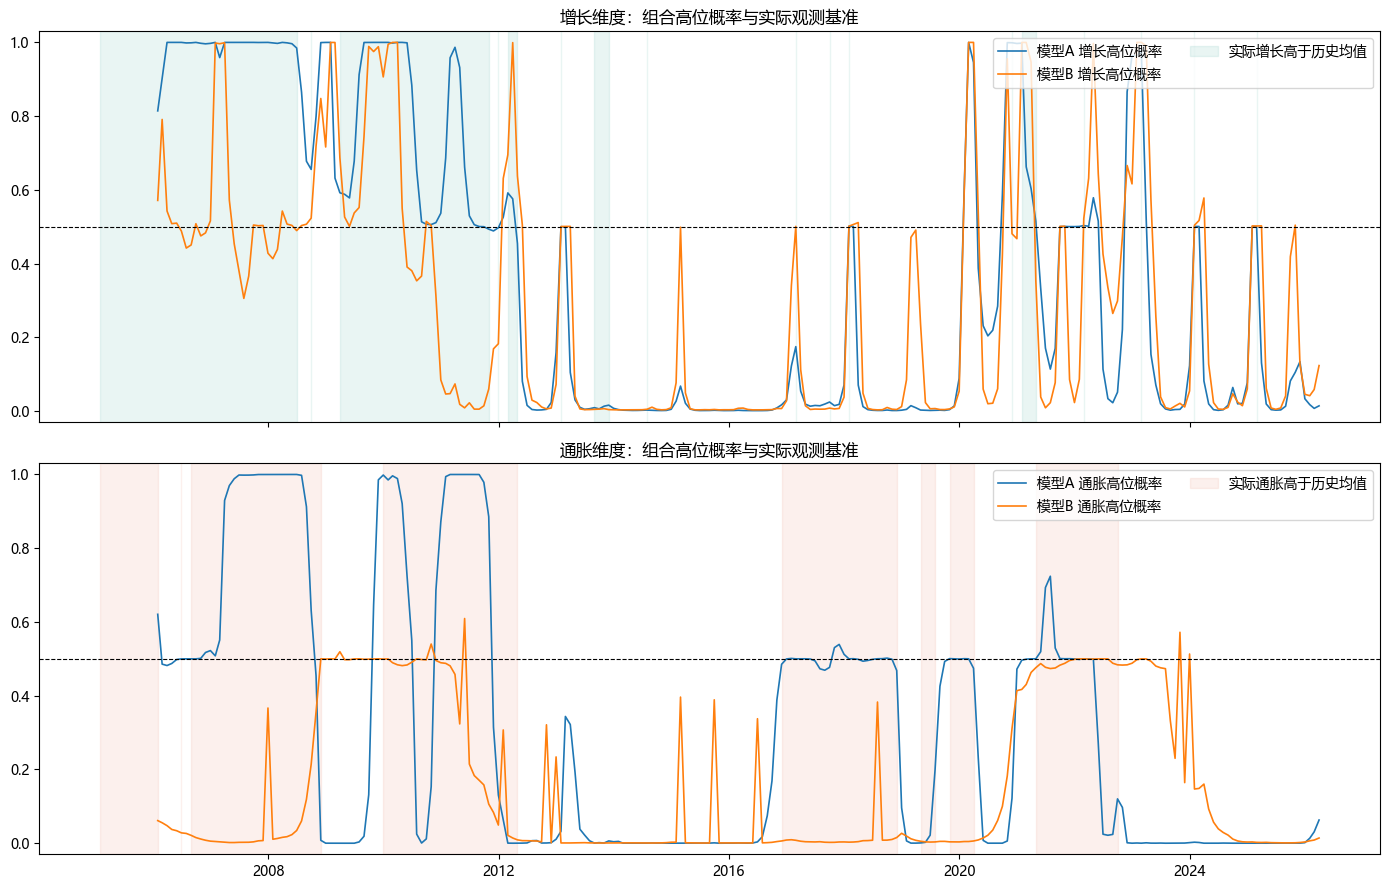

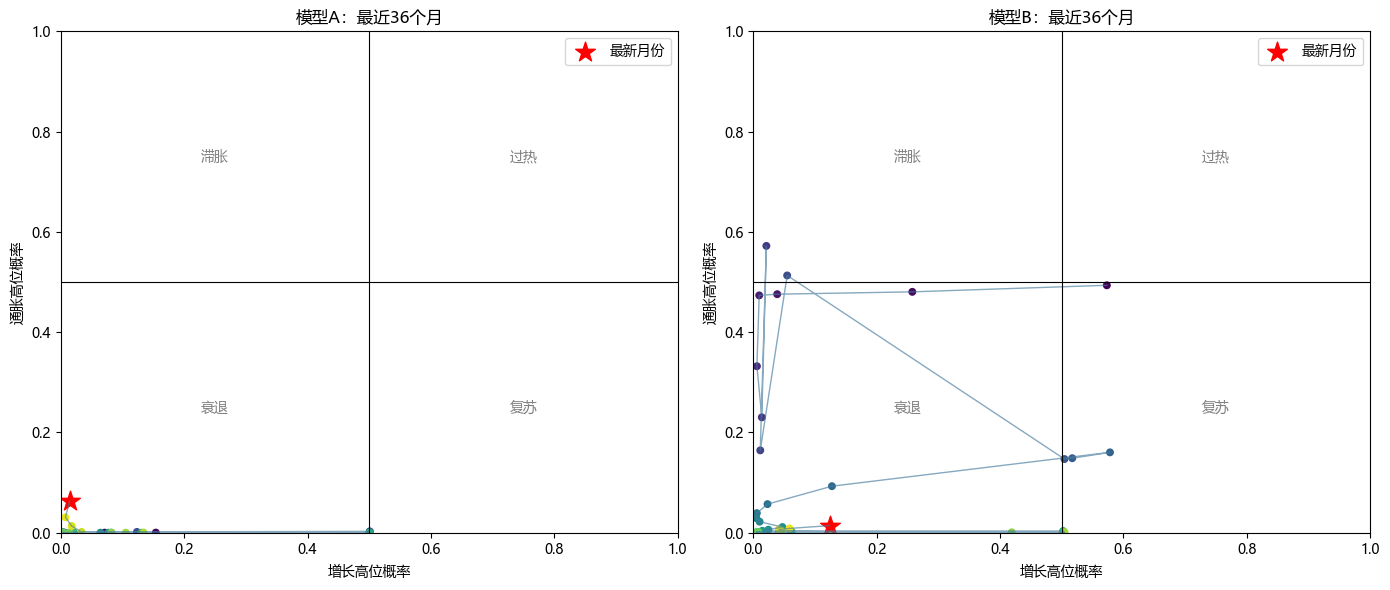

,model,date,growth_prob,inflation_prob,model_quadrant,actual_growth_score,actual_inflation_score,actual_quadrant,consistent_with_actual
0,模型A：均值—方差切换,2026-03-31 00:00:00,1.4%,6.3%,衰退,-0.413,-0.370,衰退,True
1,模型B：切换AR(1)回归,2026-03-31 00:00:00,12.4%,1.4%,衰退,-0.413,-0.370,衰退,True


,model,start_date,end_date,observations,growth_agreement,inflation_agreement,quadrant_agreement
0,模型A：均值—方差切换,2006-01-31 00:00:00,2026-03-31 00:00:00,243,84.0%,80.7%,69.5%
1,模型B：切换AR(1)回归,2006-01-31 00:00:00,2026-03-31 00:00:00,243,70.8%,53.1%,42.4%


模型A：均值—方差切换：2026-03 判定为‘衰退’，实际观测基准为‘衰退’，二者一致。
模型B：切换AR(1)回归：2026-03 判定为‘衰退’，实际观测基准为‘衰退’，二者一致。
解释提醒：模型区制衡量相对趋势的边际动能；实际基准衡量原始水平相对历史均值。二者不一致时，通常意味着水平仍高但动能转弱，或水平仍低但边际改善。


In [60]:
def macro_quadrant(growth_high, inflation_high):
    if pd.isna(growth_high) or pd.isna(inflation_high):
        return "未收敛，不给出结论"
    if growth_high and inflation_high:
        return "过热"
    if growth_high and not inflation_high:
        return "复苏"
    if not growth_high and inflation_high:
        return "滞胀"
    return "衰退"


# 整理两种模型的单指标高位概率
prob_a = model_comparison_states.pivot(index="date", columns="indicator", values="model_A_prob_high")
prob_b = model_comparison_states.pivot(index="date", columns="indicator", values="model_B_prob_high")

# 实际观测基准：原始指标各自标准化后，在增长组/通胀组内等权平均。
name_to_code = {name: code for code, name in SERIES_INFO.items()}
actual_z = pd.DataFrame(index=aligned_raw_data.index)
for name, code in name_to_code.items():
    actual_z[name] = zscore(aligned_raw_data[code])
actual = pd.DataFrame(index=actual_z.index)
actual["actual_growth_score"] = actual_z[["PMI", "工业增加值"]].mean(axis=1)
actual["actual_inflation_score"] = actual_z[["CPI", "PPI"]].mean(axis=1)
actual["actual_growth_high"] = actual["actual_growth_score"] >= 0
actual["actual_inflation_high"] = actual["actual_inflation_score"] >= 0
actual["actual_quadrant"] = [
    macro_quadrant(g, i)
    for g, i in zip(actual["actual_growth_high"], actual["actual_inflation_high"])
]

def build_macro_composite(probability_table, model_name):
    required = ["PMI", "工业增加值", "CPI", "PPI"]
    missing = [c for c in required if c not in probability_table.columns]
    if missing:
        raise KeyError(f"指标映射缺少：{missing}；请检查 SERIES_INFO 中 CPI/PMI 是否正确。")
    out = pd.DataFrame(index=probability_table.index)
    # 任一组成指标未收敛时，不以另一个指标代替整组结论。
    out["growth_prob"] = probability_table[["PMI", "工业增加值"]].mean(axis=1, skipna=False)
    out["inflation_prob"] = probability_table[["CPI", "PPI"]].mean(axis=1, skipna=False)
    out["growth_high"] = pd.array(
        np.where(out["growth_prob"].notna(), out["growth_prob"] >= PROB_THRESHOLD, pd.NA), dtype="boolean"
    )
    out["inflation_high"] = pd.array(
        np.where(out["inflation_prob"].notna(), out["inflation_prob"] >= PROB_THRESHOLD, pd.NA), dtype="boolean"
    )
    out["model_quadrant"] = [
        macro_quadrant(g, i)
        for g, i in zip(out["growth_high"], out["inflation_high"])
    ]
    out["model"] = model_name
    return out.join(actual, how="inner")

macro_a = build_macro_composite(prob_a, "模型A：均值—方差切换")
macro_b = build_macro_composite(prob_b, "模型B：切换AR(1)回归")
macro_combined = pd.concat([macro_a, macro_b]).reset_index(names="date")
macro_combined["growth_match"] = macro_combined["growth_high"] == macro_combined["actual_growth_high"]
macro_combined["inflation_match"] = macro_combined["inflation_high"] == macro_combined["actual_inflation_high"]
macro_combined["quadrant_match"] = macro_combined["model_quadrant"] == macro_combined["actual_quadrant"]

comparison_summary = macro_combined.groupby("model").agg(
    start_date=("date", "min"),
    end_date=("date", "max"),
    observations=("date", "size"),
    growth_agreement=("growth_match", "mean"),
    inflation_agreement=("inflation_match", "mean"),
    quadrant_agreement=("quadrant_match", "mean"),
).reset_index()

# 最新结论
latest_macro_rows = []
for model_name, frame in [("模型A：均值—方差切换", macro_a), ("模型B：切换AR(1)回归", macro_b)]:
    row = frame.iloc[-1]
    latest_macro_rows.append({
        "model": model_name,
        "date": frame.index[-1],
        "growth_prob": row["growth_prob"],
        "inflation_prob": row["inflation_prob"],
        "model_quadrant": row["model_quadrant"],
        "actual_growth_score": row["actual_growth_score"],
        "actual_inflation_score": row["actual_inflation_score"],
        "actual_quadrant": row["actual_quadrant"],
        "consistent_with_actual": row["model_quadrant"] == row["actual_quadrant"],
    })
latest_macro = pd.DataFrame(latest_macro_rows)

# 时间序列图：增长/通胀组合概率与实际标准化得分
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for frame, label in [(macro_a, "模型A"), (macro_b, "模型B")]:
    axes[0].plot(frame.index, frame["growth_prob"], label=f"{label} 增长高位概率", lw=1.2)
    axes[1].plot(frame.index, frame["inflation_prob"], label=f"{label} 通胀高位概率", lw=1.2)
axes[0].axhline(0.5, color="black", ls="--", lw=0.8)
axes[1].axhline(0.5, color="black", ls="--", lw=0.8)
axes[0].fill_between(actual.index, 0, 1, where=(actual["actual_growth_score"] >= 0).to_numpy(),
                     color="#2a9d8f", alpha=0.10, transform=axes[0].get_xaxis_transform(), label="实际增长高于历史均值")
axes[1].fill_between(actual.index, 0, 1, where=(actual["actual_inflation_score"] >= 0).to_numpy(),
                     color="#e76f51", alpha=0.10, transform=axes[1].get_xaxis_transform(), label="实际通胀高于历史均值")
axes[0].set_title("增长维度：组合高位概率与实际观测基准")
axes[1].set_title("通胀维度：组合高位概率与实际观测基准")
for ax in axes:
    ax.set_ylim(-0.03, 1.03)
    ax.legend(loc="upper right", ncol=2)
plt.tight_layout()
plt.savefig(OUT_DIR / "增长通胀组合_与实际状态比较.png", dpi=180, bbox_inches="tight")
plt.show()

# 四象限轨迹：仅显示最近 36 个月，终点用星号标记。
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (frame, title) in zip(axes, [(macro_a, "模型A"), (macro_b, "模型B")]):
    recent = frame.tail(36)
    ax.plot(recent["growth_prob"], recent["inflation_prob"], color="#457b9d", alpha=0.65, lw=1)
    ax.scatter(recent["growth_prob"], recent["inflation_prob"], c=np.arange(len(recent)), cmap="viridis", s=22)
    ax.scatter(recent["growth_prob"].iloc[-1], recent["inflation_prob"].iloc[-1], marker="*", s=220, color="red", label="最新月份")
    ax.axvline(0.5, color="black", lw=0.8)
    ax.axhline(0.5, color="black", lw=0.8)
    ax.text(0.75, 0.75, "过热", ha="center", va="center", transform=ax.transAxes, alpha=0.5)
    ax.text(0.75, 0.25, "复苏", ha="center", va="center", transform=ax.transAxes, alpha=0.5)
    ax.text(0.25, 0.75, "滞胀", ha="center", va="center", transform=ax.transAxes, alpha=0.5)
    ax.text(0.25, 0.25, "衰退", ha="center", va="center", transform=ax.transAxes, alpha=0.5)
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="增长高位概率", ylabel="通胀高位概率", title=f"{title}：最近36个月")
    ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "增长通胀四象限_最近36个月.png", dpi=180, bbox_inches="tight")
plt.show()

macro_combined.to_csv(OUT_DIR / "增长通胀组合_逐月状态.csv", index=False, encoding="utf-8-sig")
comparison_summary.to_csv(OUT_DIR / "增长通胀组合_实际状态一致率.csv", index=False, encoding="utf-8-sig")
latest_macro.to_csv(OUT_DIR / "增长通胀组合_最新结论.csv", index=False, encoding="utf-8-sig")

display(latest_macro.style.format({
    "growth_prob": "{:.1%}", "inflation_prob": "{:.1%}",
    "actual_growth_score": "{:.3f}", "actual_inflation_score": "{:.3f}",
}))
display(comparison_summary.style.format({
    "growth_agreement": "{:.1%}", "inflation_agreement": "{:.1%}", "quadrant_agreement": "{:.1%}",
}))

for row in latest_macro.itertuples(index=False):
    relation = "一致" if row.consistent_with_actual else "不一致"
    print(
        f"{row.model}：{row.date:%Y-%m} 判定为‘{row.model_quadrant}’，"
        f"实际观测基准为‘{row.actual_quadrant}’，二者{relation}。"
    )
print("解释提醒：模型区制衡量相对趋势的边际动能；实际基准衡量原始水平相对历史均值。二者不一致时，通常意味着水平仍高但动能转弱，或水平仍低但边际改善。")

## 2012—2020 局部训练与全样本估计的对比

本节只改变**区制切换模型的参数估计窗口**：

- 全样本方案：使用全部有效 Hamilton cycle 估计参数；
- 局部训练方案：仅使用 2012-01-31 至 2020-12-31 估计参数；
- 应用与检验时期：两种方案都在相同的完整有效样本上计算概率和状态。

Hamilton 标准化与滤波结果保持相同，目的是单独检验区制模型对训练窗口的敏感性。局部训练模型在完整时期上的概率通过固定 2012—2020 年估计参数、重新执行 Hamilton filter/smoother 得到，不在应用期重新估计。

### 为什么需要随机种子？

Markov Switching 的似然函数通常存在多个局部最优点。`search_reps` 会随机生成多组初始参数，再从较好的起点开始优化。随机种子只固定这些候选初值的生成顺序，使相同数据和代码可以复现；它不修改数据、不向模型添加噪声，也不决定最终区制。固定种子不能保证得到全局最优或保证收敛，因此仍需同时检查 `converged`、概率是否退化及参数是否合理。

In [61]:
TRAIN_START = pd.Timestamp("2012-01-31")
TRAIN_END = pd.Timestamp("2020-12-31")


def _fit_model_deterministically(model, search_reps=80):
    """固定初值概率与随机种子后估计；关闭易产生奇异矩阵的 EM 预迭代。"""
    model.initialize_known(np.array([0.5, 0.5]))
    np.random.seed(RANDOM_SEED)
    return model.fit(
        search_reps=search_reps,
        search_iter=20,
        em_iter=0,
        maxiter=3000,
        disp=False,
    )


def _smooth_with_fixed_params(model, params):
    """不重新估计参数，只在指定应用样本上运行平滑器。"""
    model.initialize_known(np.array([0.5, 0.5]))
    return model.smooth(np.asarray(params), transformed=True)


def _extract_states(result, index, centers):
    low_regime, high_regime = np.argsort(np.asarray(centers, dtype=float))
    probs = _probability_frame(result, index)
    states = pd.DataFrame(index=index)
    states["prob_low"] = probs.iloc[:, low_regime].to_numpy()
    states["prob_high"] = probs.iloc[:, high_regime].to_numpy()
    states["regime"] = np.where(states["prob_high"] >= PROB_THRESHOLD, "高位区制", "低位区制")
    return states


def estimate_and_apply_model_a(cycle, train_start=None, train_end=None):
    """模型A：在指定窗口估计，在完整 cycle 上以固定参数应用。"""
    application = cycle.astype(float).dropna()
    training = application if train_start is None else application.loc[train_start:train_end]
    if len(training) < 36:
        raise ValueError("模型A训练样本不足36个月")

    train_model = MarkovRegression(training, k_regimes=2, trend="c", switching_variance=True)
    train_result = _fit_model_deterministically(train_model, search_reps=60)
    params = _parameter_series(train_model, train_result)
    centers = [params.get("const[0]", np.nan), params.get("const[1]", np.nan)]

    application_model = MarkovRegression(application, k_regimes=2, trend="c", switching_variance=True)
    applied_result = _smooth_with_fixed_params(application_model, train_result.params)
    states = _extract_states(applied_result, application.index, centers)
    return {
        "fit_result": train_result,
        "applied_result": applied_result,
        "states": states,
        "training_n": len(training),
        "application_n": len(application),
        "avg_application_loglike": application_model.loglike(np.asarray(train_result.params)) / len(application),
        "converged": bool(train_result.mle_retvals.get("converged", False)),
    }


def estimate_and_apply_model_b(cycle, train_start=None, train_end=None):
    """模型B：切换截距/方差、共同AR(1)，指定窗口估计后应用于完整时期。"""
    application = pd.DataFrame({"cycle": cycle.astype(float)})
    application["lag1"] = application["cycle"].shift(1)
    application = application.dropna()
    training = application if train_start is None else application.loc[train_start:train_end]
    if len(training) < 36:
        raise ValueError("模型B训练样本不足36个月")

    train_model = MarkovRegression(
        training["cycle"], k_regimes=2, trend="c", exog=training[["lag1"]],
        switching_trend=True, switching_exog=False, switching_variance=True,
    )
    train_result = _fit_model_deterministically(train_model, search_reps=100)
    params = _parameter_series(train_model, train_result)
    intercepts = np.array([params.get("const[0]", np.nan), params.get("const[1]", np.nan)])
    ar_names = [n for n in params.index if n == "x1" or n == "lag1" or n.startswith("x1[") or n.startswith("lag1[")]
    phi = params[ar_names[0]] if ar_names else np.nan
    centers = intercepts / (1.0 - phi) if np.isfinite(phi) and abs(phi) < 0.98 else intercepts + phi * training["lag1"].mean()

    application_model = MarkovRegression(
        application["cycle"], k_regimes=2, trend="c", exog=application[["lag1"]],
        switching_trend=True, switching_exog=False, switching_variance=True,
    )
    applied_result = _smooth_with_fixed_params(application_model, train_result.params)
    states = _extract_states(applied_result, application.index, centers)
    return {
        "fit_result": train_result,
        "applied_result": applied_result,
        "states": states,
        "phi": phi,
        "training_n": len(training),
        "application_n": len(application),
        "avg_application_loglike": application_model.loglike(np.asarray(train_result.params)) / len(application),
        "converged": bool(train_result.mle_retvals.get("converged", False)),
    }

c:\Users\16492\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\16492\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\16492\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\16492\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\16492\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  

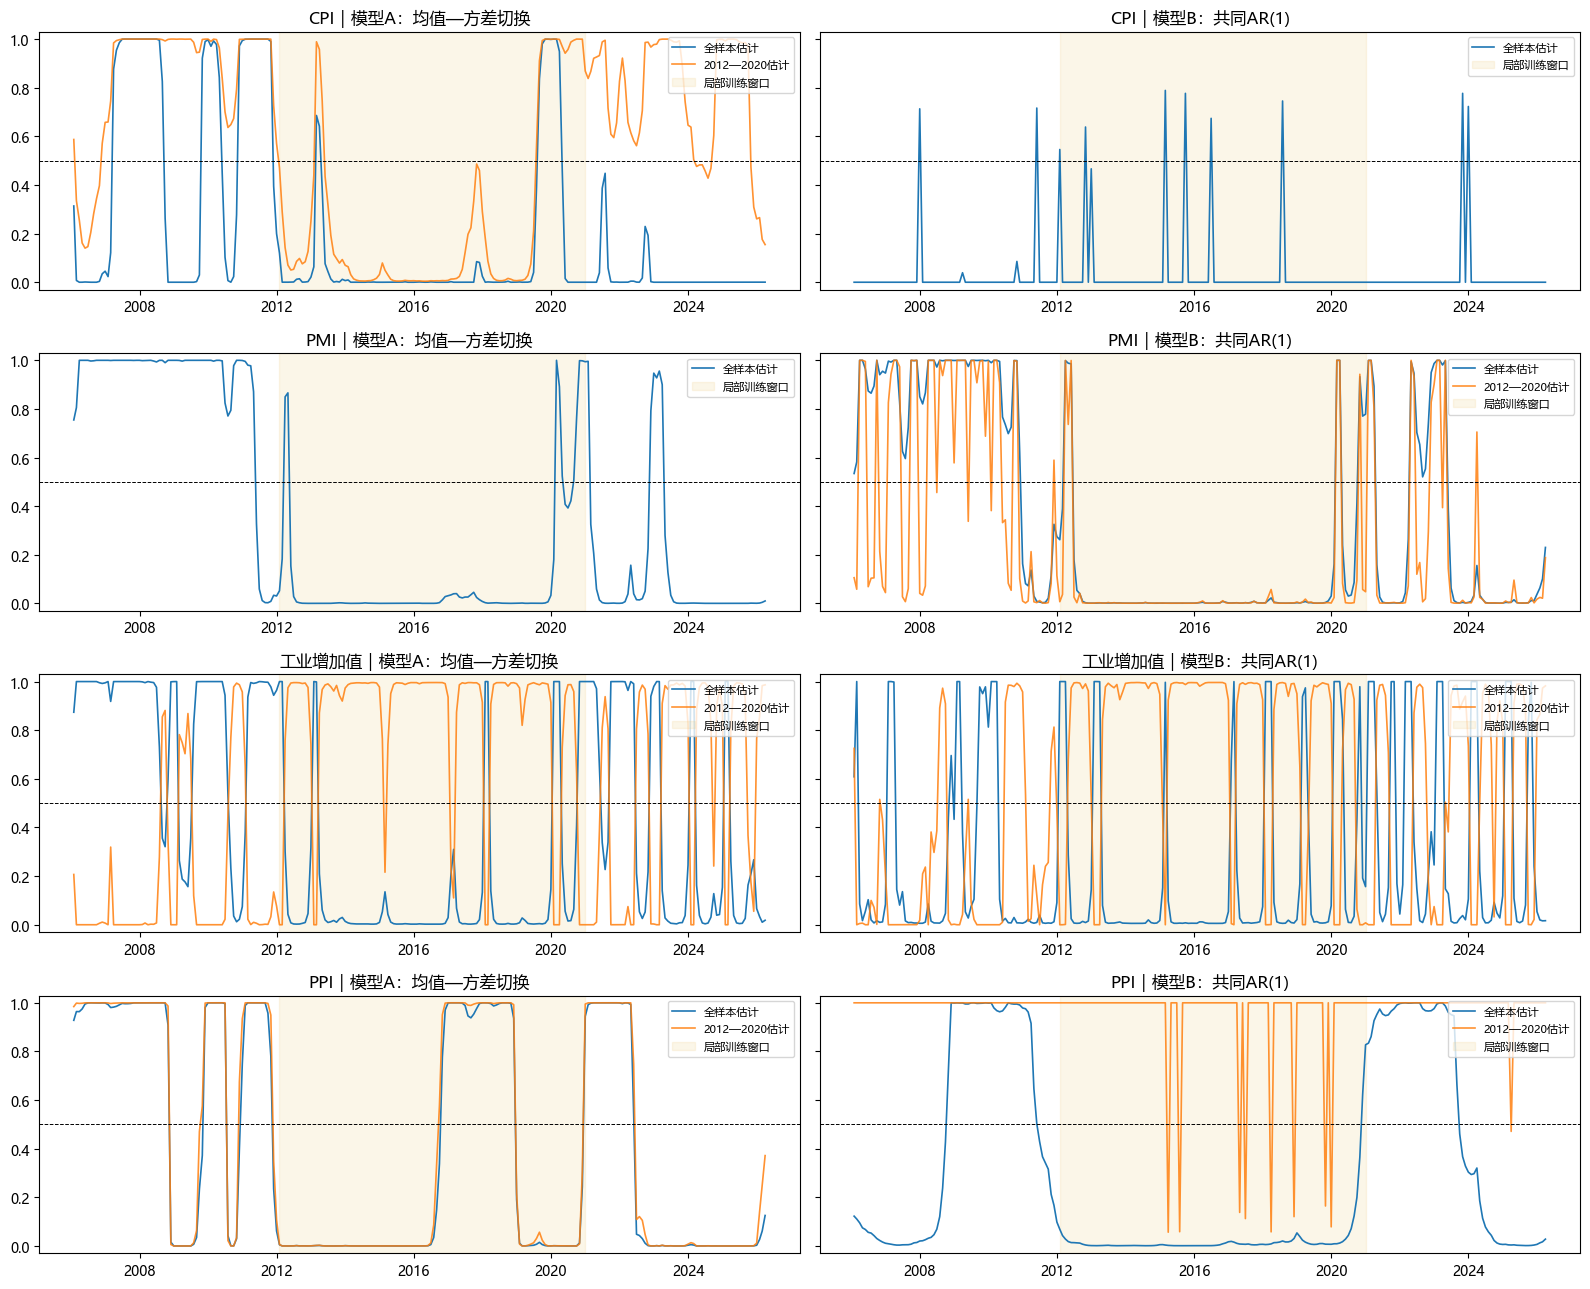

比较规则：平均应用期对数似然越高（越接近0）表示固定参数对完整时期的统计拟合越好。
注意：全样本方案在同一时期估计并评价，具有样本内优势；这里主要观察参数稳定性，不将其解释为严格样本外预测。


,code,indicator,model,application_start,application_end,full_training_n,partial_training_start,partial_training_end,partial_training_n,full_converged,partial_converged,full_latest_regime,full_latest_prob_high,partial_latest_regime,partial_latest_prob_high,latest_conclusion_consistent,historical_regime_agreement,full_avg_application_loglike,partial_avg_application_loglike,partial_minus_full_avg_loglike
0,M0000612,CPI,模型A：均值—方差切换,2006-01-31 00:00:00,2026-03-31 00:00:00,243,2012-01-31 00:00:00,2020-12-31 00:00:00,108,True,True,低位区制,0.0%,低位区制,15.5%,True,63.8%,-0.9375,-1.0921,-0.1546
1,M0000612,CPI,模型B：共同AR(1),2006-01-31 00:00:00,2026-03-31 00:00:00,243,2012-01-31 00:00:00,2020-12-31 00:00:00,108,True,False,低位区制,0.0%,未收敛,nan%,,nan%,-0.6117,-0.4727,+0.1391
2,M0017126,PMI,模型A：均值—方差切换,2006-01-31 00:00:00,2026-03-31 00:00:00,243,2012-01-31 00:00:00,2020-12-31 00:00:00,108,True,False,低位区制,1.0%,未收敛,nan%,,nan%,-0.8704,-3.4564,-2.5860
3,M0017126,PMI,模型B：共同AR(1),2006-01-31 00:00:00,2026-03-31 00:00:00,243,2012-01-31 00:00:00,2020-12-31 00:00:00,108,True,True,低位区制,23.1%,低位区制,18.9%,True,86.8%,-0.5463,-0.7938,-0.2476
4,M0000545,工业增加值,模型A：均值—方差切换,2006-01-31 00:00:00,2026-03-31 00:00:00,243,2012-01-31 00:00:00,2020-12-31 00:00:00,108,True,True,低位区制,1.8%,高位区制,98.6%,False,2.9%,-0.8341,-0.9341,-0.1000
5,M0000545,工业增加值,模型B：共同AR(1),2006-01-31 00:00:00,2026-03-31 00:00:00,243,2012-01-31 00:00:00,2020-12-31 00:00:00,108,True,True,低位区制,1.7%,高位区制,98.2%,False,24.3%,-0.5884,-0.7695,-0.1811
6,M0001227,PPI,模型A：均值—方差切换,2006-01-31 00:00:00,2026-03-31 00:00:00,243,2012-01-31 00:00:00,2020-12-31 00:00:00,108,True,True,低位区制,12.5%,低位区制,37.2%,True,98.8%,-0.8642,-1.0486,-0.1844
7,M0001227,PPI,模型B：共同AR(1),2006-01-31 00:00:00,2026-03-31 00:00:00,243,2012-01-31 00:00:00,2020-12-31 00:00:00,108,True,True,低位区制,2.8%,高位区制,100.0%,False,30.9%,-0.2924,-0.5402,-0.2478


In [62]:
window_comparison_rows = []
window_state_frames = []
window_models = {}

fig, axes = plt.subplots(len(SERIES_INFO), 2, figsize=(16, 13), sharex=False, sharey=True)

for row_i, (code, name) in enumerate(SERIES_INFO.items()):
    raw = aligned_raw_data[code].rename(code)
    cycle, _, _ = hamilton_filter(zscore(raw), H, P)

    for col_i, (model_key, estimator, model_label) in enumerate([
        ("A", estimate_and_apply_model_a, "模型A：均值—方差切换"),
        ("B", estimate_and_apply_model_b, "模型B：共同AR(1)"),
    ]):
        # 模型B因lag1损失首月；模型A同步剔除该月，保证两模型应用时期完全一致。
        model_cycle = cycle.iloc[1:] if model_key == "A" else cycle
        full_fit = estimator(model_cycle)
        partial_fit = estimator(model_cycle, TRAIN_START, TRAIN_END)
        window_models[(code, model_key, "full")] = full_fit
        window_models[(code, model_key, "2012_2020")] = partial_fit

        common_index = full_fit["states"].index.intersection(partial_fit["states"].index)
        full_states = full_fit["states"].loc[common_index]
        partial_states = partial_fit["states"].loc[common_index]
        both_valid = full_fit["converged"] and partial_fit["converged"]
        agreement = (full_states["regime"] == partial_states["regime"]).mean() if both_valid else np.nan
        latest_full = full_states.iloc[-1]
        latest_partial = partial_states.iloc[-1]

        window_comparison_rows.append({
            "code": code,
            "indicator": name,
            "model": model_label,
            "application_start": common_index[0],
            "application_end": common_index[-1],
            "full_training_n": full_fit["training_n"],
            "partial_training_start": TRAIN_START,
            "partial_training_end": TRAIN_END,
            "partial_training_n": partial_fit["training_n"],
            "full_converged": full_fit["converged"],
            "partial_converged": partial_fit["converged"],
            "full_latest_regime": latest_full["regime"] if full_fit["converged"] else "未收敛",
            "full_latest_prob_high": latest_full["prob_high"] if full_fit["converged"] else np.nan,
            "partial_latest_regime": latest_partial["regime"] if partial_fit["converged"] else "未收敛",
            "partial_latest_prob_high": latest_partial["prob_high"] if partial_fit["converged"] else np.nan,
            "latest_conclusion_consistent": (latest_full["regime"] == latest_partial["regime"]) if both_valid else pd.NA,
            "historical_regime_agreement": agreement,
            "full_avg_application_loglike": full_fit["avg_application_loglike"],
            "partial_avg_application_loglike": partial_fit["avg_application_loglike"],
            "partial_minus_full_avg_loglike": partial_fit["avg_application_loglike"] - full_fit["avg_application_loglike"],
        })

        state_frame = pd.DataFrame(index=common_index)
        state_frame["code"] = code
        state_frame["indicator"] = name
        state_frame["model"] = model_label
        state_frame["full_prob_high"] = full_states["prob_high"] if full_fit["converged"] else np.nan
        state_frame["partial_prob_high"] = partial_states["prob_high"] if partial_fit["converged"] else np.nan
        state_frame["full_regime"] = full_states["regime"] if full_fit["converged"] else "未收敛"
        state_frame["partial_regime"] = partial_states["regime"] if partial_fit["converged"] else "未收敛"
        window_state_frames.append(state_frame.reset_index(names="date"))

        ax = axes[row_i, col_i]
        if full_fit["converged"]:
            ax.plot(common_index, full_states["prob_high"], lw=1.2, label="全样本估计")
        if partial_fit["converged"]:
            ax.plot(common_index, partial_states["prob_high"], lw=1.2, label="2012—2020估计", alpha=0.85)
        ax.axvspan(TRAIN_START, TRAIN_END, color="#e9c46a", alpha=0.15, label="局部训练窗口")
        ax.axhline(PROB_THRESHOLD, color="black", ls="--", lw=0.7)
        ax.set_ylim(-0.03, 1.03)
        ax.set_title(f"{name}｜{model_label}")
        ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / "训练窗口_全样本_vs_2012_2020.png", dpi=180, bbox_inches="tight")
plt.show()

training_window_comparison = pd.DataFrame(window_comparison_rows)
training_window_states = pd.concat(window_state_frames, ignore_index=True)
training_window_comparison.to_csv(OUT_DIR / "训练窗口_结论与似然对比.csv", index=False, encoding="utf-8-sig")
training_window_states.to_csv(OUT_DIR / "训练窗口_逐月概率对比.csv", index=False, encoding="utf-8-sig")

print("比较规则：平均应用期对数似然越高（越接近0）表示固定参数对完整时期的统计拟合越好。")
print("注意：全样本方案在同一时期估计并评价，具有样本内优势；这里主要观察参数稳定性，不将其解释为严格样本外预测。")
display(training_window_comparison.style.format({
    "full_latest_prob_high": "{:.1%}",
    "partial_latest_prob_high": "{:.1%}",
    "historical_regime_agreement": "{:.1%}",
    "full_avg_application_loglike": "{:.4f}",
    "partial_avg_application_loglike": "{:.4f}",
    "partial_minus_full_avg_loglike": "{:+.4f}",
}))